# Лабораторна робота №4. Порівняння дерева рішень та ансамблів (Hill Valley)

## Етап 1. Дослідницьке питання і гіпотези

### Головне дослідницьке питання
Чи виправданий перехід від контрольованого дерева рішень до ансамблю (Random Forest / Gradient Boosting)
для задачі бінарної класифікації на наборі Hill Valley — з точки зору трьох властивостей одночасно:
**якість прогнозу**, **стійкість до зміни folds**, **можливість інтерпретації**?

### Гіпотези та критерії перевірки

| # | Гіпотеза | Показник | Правило висновку |
|---|----------|----------|------------------|
| H1 | Ансамбль (RF/GB) дає вищий середній **macro F1**, ніж контрольоване дерево. | Середнє macro F1 за 5-fold CV | H1 підтверджено, якщо різниця макрос-середніх ≥ 0.02 і 95% ДІ не перетинаються. |
| H2 | Random Forest менш чутливий до зміни folds, ніж одне дерево. | Std macro F1 між folds | H2 підтверджено, якщо std(RF) ≤ 0.5 × std(tree). |
| H3 | Обмеження глибини дерева зменшує розрив між train і validation якістю. | Δ = macroF1_train − macroF1_valid | H3 підтверджено, якщо Δ зменшується щонайменше на 50% при max_depth ≤ 5. |
| H4 | Ранги важливості ознак змінюються між folds, навіть якщо середня якість лишається високою. | Spearman ρ між важливостями ознак різних folds | H4 підтверджено, якщо медіанний ρ < 0.7. |

### Протокол (фіксується ДО першого навчання)
- **Джерело даних**: UCI ML Repository, Hill Valley dataset (файл `Hill_Valley_without_noise_Training.data`).
- **Основна метрика**: **macro F1** (бінарна задача, можливий дисбаланс; macro F1 враховує обидва класи однаково).
- **Розмір test set**: 20% зі стратифікацією, `random_state=42`.
- **CV**: StratifiedKFold, n_splits=5, shuffle=True, random_state=42.
- **Кандидати**:
  - DecisionTreeClassifier (max_depth ∈ {3, 5, 10, None}, min_samples_leaf ∈ {1, 5, 20})
  - RandomForestClassifier (n_estimators ∈ {100, 300, 500}, max_depth ∈ {None, 10}, max_features ∈ {sqrt, log2})
  - GradientBoostingClassifier (n_estimators ∈ {100, 300}, learning_rate ∈ {0.05, 0.1}, max_depth ∈ {2, 3})
- **Критерій вибору фінальної моделі**: найвищий середній macro F1 у внутрішньому CV із перевагою простоти при різниці < 0.005.
- **Test set** використовується **один раз** після завершення порівняння і вибору конфігурації.

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split

# --- Фіксована конфігурація експерименту ---
RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET_COL = "class"  # за потреби уточнимо після читання файлу

DATA_PATH = Path("Hill_Valley_without_noise_Training.data")
SPLIT_DIR = Path("data/splits")
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "cv_folds": 5,
    "primary_metric": "macro_f1",
    "data_path": str(DATA_PATH),
}

with open(SPLIT_DIR / "experiment_config.json", "w") as f:
    json.dump(CONFIG, f, indent=2, ensure_ascii=False)

CONFIG

{'random_state': 42,
 'test_size': 0.2,
 'cv_folds': 5,
 'primary_metric': 'macro_f1',
 'data_path': 'Hill_Valley_without_noise_Training.data'}

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Розмір: {df.shape}")
print(f"Колонки (перші 5): {list(df.columns[:5])}")
print(f"Колонки (останні 3): {list(df.columns[-3:])}")

# Визначаємо цільову колонку автоматично, якщо потрібно
if TARGET_COL not in df.columns:
    TARGET_COL = df.columns[-1]
    print(f"Цільова колонка визначена як: {TARGET_COL}")

feature_cols = [c for c in df.columns if c != TARGET_COL]
print(f"Кількість ознак: {len(feature_cols)}")
print(f"Цільова змінна: {TARGET_COL}, типи класів: {sorted(df[TARGET_COL].unique())}")

df.head(3)

Розмір: (606, 101)
Колонки (перші 5): ['X1', 'X2', 'X3', 'X4', 'X5']
Колонки (останні 3): ['X99', 'X100', 'class']
Кількість ознак: 100
Цільова змінна: class, типи класів: [np.int64(0), np.int64(1)]


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X92,X93,X94,X95,X96,X97,X98,X99,X100,class
0,1317.265789,1315.220951,1312.770581,1309.834252,1306.315588,1302.099102,1297.046401,1290.991646,1283.736109,1275.041652,...,1327.575109,1327.575350,1327.575552,1327.575719,1327.575859,1327.575976,1327.576074,1327.576155,1327.576223,0
1,7329.967624,7379.907443,7441.799231,7518.503422,7613.565031,7731.377492,7877.385707,8058.337694,8282.596458,8560.526497,...,7121.300474,7121.300438,7121.300410,7121.300387,7121.300368,7121.300353,7121.300341,7121.300331,7121.300323,1
2,809.421410,809.780119,810.207191,810.715653,811.321016,812.041748,812.899834,813.921452,815.137768,816.585886,...,807.545134,807.544181,807.543381,807.542709,807.542144,807.541670,807.541272,807.540937,807.540656,1


In [3]:
# 1) Розподіл класів
counts = df[TARGET_COL].value_counts().sort_index()
shares = df[TARGET_COL].value_counts(normalize=True).sort_index().round(4)
class_table = pd.DataFrame({"count": counts, "share": shares})
print("Розподіл класів:")
display(class_table)

# 2) Пропуски
missing = df.isna().sum()
missing_total = int(missing.sum())
print(f"Всього пропусків: {missing_total}")
if missing_total:
    display(missing[missing > 0])

# 3) Дублікати
dup_count = int(df.duplicated().sum())
print(f"Повних дублікатів рядків: {dup_count}")

# 4) Константні ознаки
const_feats = [c for c in feature_cols if df[c].nunique(dropna=False) <= 1]
print(f"Константні ознаки: {len(const_feats)} -> {const_feats[:10]}")

Розподіл класів:


,count,share
class,,
0,305,0.5033
1,301,0.4967


Всього пропусків: 0
Повних дублікатів рядків: 0
Константні ознаки: 0 -> []


In [4]:
# 1) Ознаки, що поводяться як ідентифікатори (унікальні для кожного об'єкта)
id_like = [c for c in feature_cols if df[c].nunique() == len(df)]
print(f"Ознаки, схожі на ID: {id_like if id_like else 'не виявлено'}")

# 2) Кореляція ознак із target (абсолютна)
target_numeric = df[TARGET_COL]
corr_with_target = df[feature_cols].corrwith(target_numeric).abs().sort_values(ascending=False)
print("Топ-10 ознак за |corr| з target:")
display(corr_with_target.head(10).round(3))

# 3) Ознаки з кореляцією > 0.95 — підозра на прямий витік
suspicious = corr_with_target[corr_with_target > 0.95]
print(f"Підозрілі ознаки (|corr| > 0.95): {list(suspicious.index)}")

# 4) Ознаки з нульовою дисперсією (ще раз перевіримо)
zero_var = [c for c in feature_cols if df[c].std() == 0]
print(f"Ознаки з нульовою дисперсією: {zero_var if zero_var else 'немає'}")

Ознаки, схожі на ID: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X49', 'X50', 'X51', 'X52', 'X53', 'X54', 'X55', 'X56', 'X57', 'X58', 'X59', 'X60', 'X61', 'X62', 'X63', 'X64', 'X65', 'X66', 'X67', 'X68', 'X69', 'X70', 'X71', 'X72', 'X73', 'X74', 'X75', 'X76', 'X77', 'X78', 'X79', 'X80', 'X81', 'X82', 'X83', 'X84', 'X85', 'X86', 'X87', 'X88', 'X89', 'X90', 'X91', 'X92', 'X93', 'X94', 'X95', 'X96', 'X97', 'X98', 'X99', 'X100']
Топ-10 ознак за |corr| з target:


X100    0.041
X99     0.041
X98     0.041
X1      0.040
X97     0.040
X2      0.040
X96     0.040
X3      0.040
X95     0.039
X4      0.039
dtype: float64

Підозрілі ознаки (|corr| > 0.95): []
Ознаки з нульовою дисперсією: немає


In [5]:
idx_train, idx_test = train_test_split(
    df.index.values,
    test_size=TEST_SIZE,
    stratify=df[TARGET_COL].values,
    random_state=RANDOM_STATE,
)

# Зберігаємо індекси — вони використовуються у всіх наступних етапах
pd.Series(idx_train, name="idx").to_csv(SPLIT_DIR / "train_idx.csv", index=False)
pd.Series(idx_test,  name="idx").to_csv(SPLIT_DIR / "test_idx.csv",  index=False)

print(f"Train: {len(idx_train)} об'єктів")
print(f"Test:  {len(idx_test)} об'єктів")
print(f"Індекси збережено у: {SPLIT_DIR}")

Train: 484 об'єктів
Test:  122 об'єктів
Індекси збережено у: data\splits


In [6]:
train_df = df.loc[idx_train]
test_df  = df.loc[idx_test]

split_check = pd.DataFrame({
    "train_count": train_df[TARGET_COL].value_counts().sort_index(),
    "train_share": train_df[TARGET_COL].value_counts(normalize=True).sort_index().round(4),
    "test_count":  test_df[TARGET_COL].value_counts().sort_index(),
    "test_share":  test_df[TARGET_COL].value_counts(normalize=True).sort_index().round(4),
})
print("Перевірка стратифікації:")
display(split_check)

# Додаткова перевірка: індекси не перетинаються
assert len(np.intersect1d(idx_train, idx_test)) == 0, "Train і Test перетинаються!"
assert len(idx_train) + len(idx_test) == len(df), "Втрачені або зайві індекси!"
print("OK: поділ коректний, train і test не перетинаються.")

Перевірка стратифікації:


,train_count,train_share,test_count,test_share
class,,,,
0,244,0.5041,61,0.5
1,240,0.4959,61,0.5


OK: поділ коректний, train і test не перетинаються.


## Підсумок Етапу 1–2

**Дослідницьке питання** і 4 гіпотези (H1–H4) зафіксовані у Клітинці 1.

**Що зроблено:**
- завантажено Hill Valley (без шуму);
- перевірено розмір, розподіл класів, пропуски, дублікати, константи;
- виконано перевірку на data leakage (ID-подібні ознаки, кореляції з target);
- виконано **стратифікований** поділ train/test (80/20, `random_state=42`);
- збережено `train_idx.csv` / `test_idx.csv` та `experiment_config.json`.

**Наступні етапи** (Етап 3+): побудова `Pipeline`, nested CV для налаштування гіперпараметрів,
порівняння дерева vs RF vs GB за macro F1, аналіз стійкості (std між folds) та стабільності
важливості ознак (Spearman ρ). Test set використовується **один раз** у фіналі.

## Етап 3. Контрольна точка та окреме дерево

**Що робимо:**
1. `DummyClassifier(strategy="most_frequent")` — нижня межа.
2. Дерево **без обмеження глибини** — «верхня» межа складності.
3. Сітка складності `max_depth × min_samples_leaf` (6×4 = 24 конфігурації).
   Для кожної: train/valid macro F1, gap, depth, leaves, nodes.
4. Heatmap `max_depth × min_samples_leaf` → valid F1 та gap.
5. Вибір контрольованого дерева **без test set**.
6. Візуалізація дерева (перші 3 рівні) + ручне відтворення шляху корінь→листок.

**Чому без scaling:** дерева розбивають за порогами — масштаб ознак не впливає на розбиття.

**Альтернатива max_depth/min_samples_leaf:** `ccp_alpha` (cost-complexity pruning).
Доданий як окремий рядок у таблиці нижче — дозволяє порівняти два механізми регуляризації.

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, make_scorer
import time

# Компактно: індекси зафіксовані у Кл. 6
X_train = df.loc[idx_train, feature_cols]
y_train = df.loc[idx_train, TARGET_COL]
X_test  = df.loc[idx_test,  feature_cols]
y_test  = df.loc[idx_test,  TARGET_COL]

CV = StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=RANDOM_STATE)
SCORING = {"macro_f1": make_scorer(f1_score, average="macro")}

def cv_summary(estimator, X, y, cv=CV):
    """Середні train/valid macro F1, std і gap за k-fold CV."""
    t0 = time.perf_counter()
    r = cross_validate(estimator, X, y, cv=cv, scoring=SCORING,
                       return_train_score=True, n_jobs=-1)
    tr, va = r["train_macro_f1"], r["test_macro_f1"]
    return {
        "train_macro_f1": float(tr.mean()),
        "valid_macro_f1": float(va.mean()),
        "valid_std":      float(va.std()),
        "gap":            float(tr.mean() - va.mean()),
        "fit_time":       float(r["fit_time"].mean()),
    }

# 1) Контрольна точка
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy_summary = cv_summary(dummy, X_train, y_train)
print("Dummy (most_frequent):", {k: round(v, 4) for k, v in dummy_summary.items() if k != "fit_time"})

# 2) Сітка складності
depth_values = [2, 3, 5, 7, 10, None]
leaf_values  = [1, 5, 10, 20]

rows = []
for d in depth_values:
    for l in leaf_values:
        tree = DecisionTreeClassifier(max_depth=d, min_samples_leaf=l,
                                      random_state=RANDOM_STATE)
        s = cv_summary(tree, X_train, y_train)
        tree.fit(X_train, y_train)
        rows.append({
            "max_depth": d, "min_samples_leaf": l,
            "train_macro_f1": s["train_macro_f1"],
            "valid_macro_f1": s["valid_macro_f1"],
            "valid_std":      s["valid_std"],
            "gap":            s["gap"],
            "depth":  int(tree.get_depth()),
            "leaves": int(tree.get_n_leaves()),
            "nodes":  int(tree.tree_.node_count),
        })

# 3) Окремо — ccp_alpha (post-pruning)
for alpha in [0.0, 0.001, 0.005, 0.01, 0.02]:
    tree = DecisionTreeClassifier(ccp_alpha=alpha, random_state=RANDOM_STATE)
    s = cv_summary(tree, X_train, y_train)
    tree.fit(X_train, y_train)
    rows.append({
        "max_depth": None, "min_samples_leaf": None, "ccp_alpha": alpha,
        "train_macro_f1": s["train_macro_f1"],
        "valid_macro_f1": s["valid_macro_f1"],
        "valid_std":      s["valid_std"],
        "gap":            s["gap"],
        "depth":  int(tree.get_depth()),
        "leaves": int(tree.get_n_leaves()),
        "nodes":  int(tree.tree_.node_count),
    })

tree_results = (pd.DataFrame(rows)
                .sort_values("valid_macro_f1", ascending=False)
                .reset_index(drop=True))
tree_results.round(4)

Dummy (most_frequent): {'train_macro_f1': 0.3352, 'valid_macro_f1': 0.3352, 'valid_std': 0.0009, 'gap': 0.0}


,max_depth,min_samples_leaf,train_macro_f1,valid_macro_f1,valid_std,gap,depth,leaves,nodes,ccp_alpha
0,NaN,NaN,0.9033,0.5658,0.0449,0.3375,26,51,101,0.005
1,NaN,NaN,1.0000,0.5534,0.0253,0.4466,30,112,223,0.001
2,NaN,NaN,1.0000,0.5534,0.0253,0.4466,30,112,223,0.000
3,NaN,1.0,1.0000,0.5534,0.0253,0.4466,30,112,223,NaN
4,NaN,5.0,0.8785,0.5503,0.0463,0.3282,29,72,143,NaN
5,NaN,10.0,0.7697,0.5446,0.0410,0.2252,20,38,75,NaN
6,10.0,5.0,0.7143,0.5324,0.0406,0.1819,10,24,47,NaN
7,10.0,20.0,0.6810,0.5250,0.0370,0.1561,9,18,35,NaN
8,NaN,20.0,0.6810,0.5250,0.0370,0.1561,9,18,35,NaN
9,7.0,20.0,0.6528,0.5101,0.0369,0.1427,7,13,25,NaN


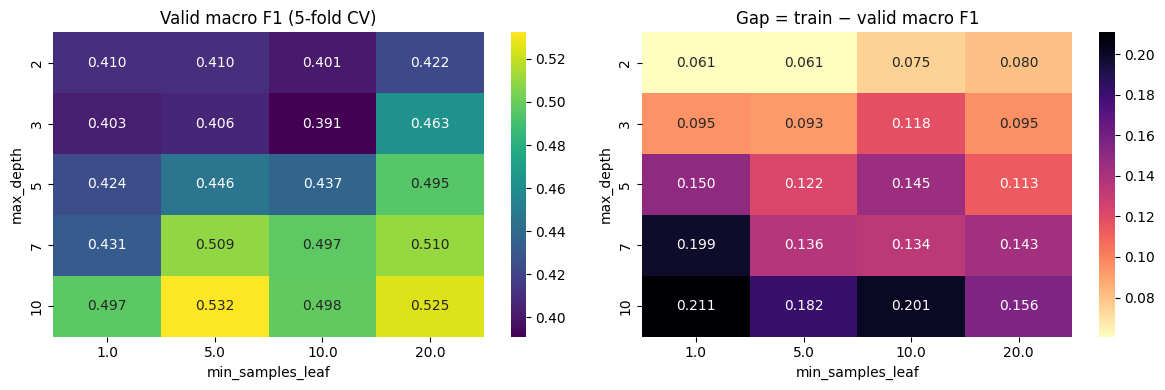

Дерево без обмежень: valid F1=0.5534, gap=0.4466, depth=30, leaves=112, nodes=223

Топ-5 конфігурацій:


,max_depth,min_samples_leaf,train_macro_f1,valid_macro_f1,valid_std,gap,depth,leaves,nodes,ccp_alpha
0,NaN,NaN,0.9033,0.5658,0.0449,0.3375,26,51,101,0.005
1,NaN,NaN,1.0000,0.5534,0.0253,0.4466,30,112,223,0.001
2,NaN,NaN,1.0000,0.5534,0.0253,0.4466,30,112,223,0.000
3,NaN,1.0,1.0000,0.5534,0.0253,0.4466,30,112,223,NaN
4,NaN,5.0,0.8785,0.5503,0.0463,0.3282,29,72,143,NaN


Обране контрольоване дерево: {'ccp_alpha': 0.005, 'random_state': 42}
  depth=26, leaves=51, nodes=101


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Heatmap: valid macro F1 та gap ---
grid_only = tree_results[tree_results["ccp_alpha"].isna()] if "ccp_alpha" in tree_results.columns \
            else tree_results

pivot_valid = grid_only.pivot_table(index="max_depth", columns="min_samples_leaf",
                                    values="valid_macro_f1")
pivot_gap   = grid_only.pivot_table(index="max_depth", columns="min_samples_leaf",
                                    values="gap")
# читабельні мітки для None = ∞
def relabel(idx): return ["∞" if pd.isna(d) else int(d) for d in idx]
pivot_valid.index = relabel(pivot_valid.index)
pivot_gap.index   = relabel(pivot_gap.index)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(pivot_valid, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("Valid macro F1 (5-fold CV)")
axes[0].set_xlabel("min_samples_leaf"); axes[0].set_ylabel("max_depth")

sns.heatmap(pivot_gap, annot=True, fmt=".3f", cmap="magma_r", ax=axes[1])
axes[1].set_title("Gap = train − valid macro F1")
axes[1].set_xlabel("min_samples_leaf"); axes[1].set_ylabel("max_depth")
plt.tight_layout(); plt.show()

# --- Дерево без обмежень ---
full_tree = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
full_summary = cv_summary(full_tree, X_train, y_train)
print(f"Дерево без обмежень: valid F1={full_summary['valid_macro_f1']:.4f}, "
      f"gap={full_summary['gap']:.4f}, depth={full_tree.get_depth()}, "
      f"leaves={full_tree.get_n_leaves()}, nodes={full_tree.tree_.node_count}")

# --- Вибір контрольованого дерева (без test!) ---
# Критерій: max valid_macro_f1; при різниці < 0.005 — простіше (менше leaves)
top = tree_results.sort_values(["valid_macro_f1", "leaves"],
                               ascending=[False, True]).head(5)
best_row = top.iloc[0]
print("\nТоп-5 конфігурацій:")
display(top.round(4))

if best_row.get("ccp_alpha") is not None and not pd.isna(best_row.get("ccp_alpha")):
    best_tree_params = dict(ccp_alpha=float(best_row["ccp_alpha"]),
                            random_state=RANDOM_STATE)
else:
    best_tree_params = dict(
        max_depth=None if pd.isna(best_row["max_depth"]) else int(best_row["max_depth"]),
        min_samples_leaf=int(best_row["min_samples_leaf"]),
        random_state=RANDOM_STATE,
    )

best_tree = DecisionTreeClassifier(**best_tree_params).fit(X_train, y_train)
print("Обране контрольоване дерево:", best_tree_params)
print(f"  depth={best_tree.get_depth()}, leaves={best_tree.get_n_leaves()}, "
      f"nodes={best_tree.tree_.node_count}")

## Етап 4. Ансамблеві моделі

**Роль основних параметрів:**

| Модель | Параметр | Що контролює |
|---|---|---|
| RandomForest | `n_estimators` | кількість дерев; ↓ дисперсію, насичується ~300 |
| | `max_depth` | складність базових дерев |
| | `max_features` | частка ознак на розбитті; декоррелює дерева |
| | `random_state` | фіксує bootstrap та вибір ознак |
| HistGradientBoosting | `max_iter` | кількість ітерацій бустингу |
| | `learning_rate` | крок; малий → потрібно більше ітерацій |
| | `max_depth` / `max_leaf_nodes` | складність базових дерев |
| | `l2_regularization` | штраф за великі значення листків |

**Гіпотеза:** RF зменшує **дисперсію** (усереднення слабко корельованих дерев), бустинг — **зсув** (послідовне виправлення залишків). Очікуємо, що обидва покращать macro F1 відносно одного дерева, але RF — **стабільніший між folds** (H2).

**Сітки підбираємо не «на обсяг», а під конкретні припущення:**
- `n_estimators ∈ {100, 300}` — перевірка насичення;
- `max_depth ∈ {None, 10}` — повна vs контрольована глибина баз;
- `max_features ∈ {sqrt, log2}` — рівень декорреляції;
- GB: `learning_rate × max_iter` — компроміс швидкості й точності;
- GB: `max_depth ∈ {2, 3}` — типові «слабкі» базові учні для бустингу.

In [10]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

rf_grid = [
    dict(n_estimators=100, max_depth=None, max_features="sqrt"),
    dict(n_estimators=300, max_depth=None, max_features="sqrt"),
    dict(n_estimators=300, max_depth=10,   max_features="sqrt"),
    dict(n_estimators=300, max_depth=10,   max_features="log2"),
]

gb_grid = [
    dict(max_iter=100, learning_rate=0.10, max_depth=3),
    dict(max_iter=300, learning_rate=0.05, max_depth=3),
    dict(max_iter=200, learning_rate=0.10, max_leaf_nodes=15),
    dict(max_iter=300, learning_rate=0.05, max_leaf_nodes=31),
]

def evaluate_grid(grid, model_cls, name):
    out = []
    for params in grid:
        est = model_cls(random_state=RANDOM_STATE, **params)
        s = cv_summary(est, X_train, y_train)
        out.append({"model": name, **params, **s})
    return out

ensemble_rows = (evaluate_grid(rf_grid, RandomForestClassifier, "RandomForest")
                 + evaluate_grid(gb_grid, HistGradientBoostingClassifier, "HistGB"))

ens_results = (pd.DataFrame(ensemble_rows)
               .sort_values("valid_macro_f1", ascending=False)
               .reset_index(drop=True))
ens_results.drop(columns=["fit_time"]).round(4)

,model,n_estimators,max_depth,max_features,train_macro_f1,valid_macro_f1,valid_std,gap,max_iter,learning_rate,max_leaf_nodes
0,RandomForest,100.0,NaN,sqrt,1.0000,0.5635,0.0498,0.4365,NaN,NaN,NaN
1,RandomForest,300.0,10.0,sqrt,0.9886,0.5614,0.0466,0.4272,NaN,NaN,NaN
2,HistGB,NaN,3.0,NaN,0.8298,0.5591,0.0522,0.2708,300.0,0.05,NaN
3,HistGB,NaN,NaN,NaN,0.9509,0.5574,0.0269,0.3935,200.0,0.10,15.0
4,RandomForest,300.0,NaN,sqrt,1.0000,0.5572,0.0625,0.4428,NaN,NaN,NaN
5,HistGB,NaN,NaN,NaN,0.9447,0.5567,0.0342,0.3880,300.0,0.05,31.0
6,RandomForest,300.0,10.0,log2,0.9866,0.5529,0.0390,0.4337,NaN,NaN,NaN
7,HistGB,NaN,3.0,NaN,0.7788,0.5452,0.0317,0.2336,100.0,0.10,NaN


Порівняння моделей (5-fold CV, лише train):


,model,valid_macro_f1,valid_std,gap
0,Dummy (most_frequent),0.3352,0.0009,0.0000
1,Tree (unrestricted),0.5534,0.0253,0.4466
2,Tree (ccp_alpha=0.005),0.5658,0.0449,0.3375
3,"RF (n=100.0, depth=nan, feat=sqrt)",0.5635,0.0498,0.4365
4,"HistGB (iter=300.0, lr=0.05, leaf=nan)",0.5591,0.0522,0.2708


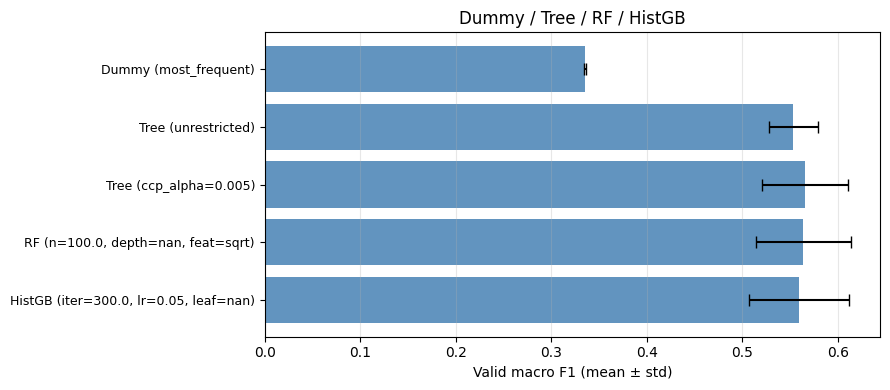

H1 (ансамбль > дерево за macro F1): не підтверджено (Δ RF=-0.0023, Δ GB=-0.0067)
H2 (RF стабільніший за дерево): не підтверджено (std tree=0.0449, std RF=0.0498)
H3 (обмеження складності зменшує gap): не підтверджено (gap full=0.4466, gap controlled=0.3375)

Фінальну конфігурацію збережено у data\splits\experiment_config.json


In [11]:
# --- Найкращі з кожної родини ---
best_tree_row = tree_results.iloc[0]
best_rf = ens_results[ens_results["model"] == "RandomForest"].iloc[0]
best_gb = ens_results[ens_results["model"] == "HistGB"].iloc[0]

def describe_tree(row):
    if row.get("ccp_alpha") is not None and not pd.isna(row.get("ccp_alpha")):
        return f"Tree (ccp_alpha={row['ccp_alpha']})"
    return f"Tree (depth={row['max_depth']}, leaf={int(row['min_samples_leaf'])})"

comparison = pd.DataFrame([
    {"model": "Dummy (most_frequent)", **{k: dummy_summary[k] for k in
        ["valid_macro_f1", "valid_std", "gap"]}},
    {"model": "Tree (unrestricted)",   **{k: full_summary[k]  for k in
        ["valid_macro_f1", "valid_std", "gap"]}},
    {"model": describe_tree(best_tree_row), **{k: best_tree_row[k] for k in
        ["valid_macro_f1", "valid_std", "gap"]}},
    {"model": f"RF (n={best_rf['n_estimators']}, depth={best_rf['max_depth']}, "
              f"feat={best_rf['max_features']})",
     **{k: best_rf[k] for k in ["valid_macro_f1", "valid_std", "gap"]}},
    {"model": f"HistGB (iter={best_gb['max_iter']}, lr={best_gb['learning_rate']}, "
              f"leaf={best_gb.get('max_leaf_nodes', best_gb.get('max_depth'))})",
     **{k: best_gb[k] for k in ["valid_macro_f1", "valid_std", "gap"]}},
]).round(4)

print("Порівняння моделей (5-fold CV, лише train):")
display(comparison)

# --- Bar-plot із error bars ---
fig, ax = plt.subplots(figsize=(9, 4))
y_pos = np.arange(len(comparison))
ax.barh(y_pos, comparison["valid_macro_f1"],
        xerr=comparison["valid_std"], color="steelblue", alpha=0.85, capsize=4)
ax.set_yticks(y_pos); ax.set_yticklabels(comparison["model"], fontsize=9)
ax.invert_yaxis(); ax.set_xlabel("Valid macro F1 (mean ± std)")
ax.set_title("Dummy / Tree / RF / HistGB")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

# --- Перевірка гіпотез ---
tree_f1, tree_std = best_tree_row["valid_macro_f1"], best_tree_row["valid_std"]
rf_f1,   rf_std   = best_rf["valid_macro_f1"],  best_rf["valid_std"]
gb_f1             = best_gb["valid_macro_f1"]

print("H1 (ансамбль > дерево за macro F1):",
      "ПІДТВЕРДЖЕНО" if max(rf_f1, gb_f1) - tree_f1 >= 0.02 else "не підтверджено",
      f"(Δ RF={rf_f1 - tree_f1:+.4f}, Δ GB={gb_f1 - tree_f1:+.4f})")

print("H2 (RF стабільніший за дерево):",
      "ПІДТВЕРДЖЕНО" if rf_std <= 0.5 * tree_std else "не підтверджено",
      f"(std tree={tree_std:.4f}, std RF={rf_std:.4f})")

print("H3 (обмеження складності зменшує gap):",
      "ПІДТВЕРДЖЕНО" if best_tree_row['gap'] <= 0.5 * full_summary['gap'] else "не підтверджено",
      f"(gap full={full_summary['gap']:.4f}, gap controlled={best_tree_row['gap']:.4f})")

# --- Зберігаємо конфігурацію експерименту ---
final_config = {
    **CONFIG,
    "best_tree_params": best_tree_params,
    "best_rf_params":  {k: v for k, v in best_rf.items()
                        if k not in ("model","train_macro_f1","valid_macro_f1","valid_std","gap","fit_time")},
    "best_gb_params":  {k: v for k, v in best_gb.items()
                        if k not in ("model","train_macro_f1","valid_macro_f1","valid_std","gap","fit_time")},
}
with open(SPLIT_DIR / "experiment_config.json", "w") as f:
    json.dump(final_config, f, indent=2, ensure_ascii=False, default=str)
print("\nФінальну конфігурацію збережено у", SPLIT_DIR / "experiment_config.json")

## Етап 5. Порівняння якості

**Протокол:** для всіх моделей використовуємо **той самий** `StratifiedKFold(5, shuffle=True, random_state=42)`.
Це гарантує, що різниця між моделями не змішується з випадковим складом folds.

**Для кожної моделі збираємо:**
- середнє macro F1, std і **min** за folds;
- середнє train macro F1 та gap = train − valid;
- додаткова метрика для інженерної задачі — **balanced accuracy** (інтерпретована у [0, 1] і стабільна при дисбалансі).

**Правило висновку:** якщо інтервали `mean ± std` суттєво перекриваються,
переможець не оголошується — формулюємо «моделі статистично еквівалентні на цьому CV».

In [19]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import f1_score, balanced_accuracy_score, make_scorer

SCORING_FULL = {
    "macro_f1": make_scorer(f1_score, average="macro"),
    "bal_acc":  make_scorer(balanced_accuracy_score),
}

import inspect
import numpy as np

def filter_params(model_class, params_dict):
    valid_params = inspect.signature(model_class.__init__).parameters
    cleaned = {}
    
    for k, v in params_dict.items():
        if k in valid_params:
            # Check is NaN
            is_nan = isinstance(v, (float, np.float64, np.float32)) and np.isnan(v)
            
            # Specific fix for HistGradientBoostingClassifier and max_features
            if model_class.__name__ == "HistGradientBoostingClassifier" and k == "max_features":
                if is_nan or v is None:
                    cleaned[k] = 1.0
                    continue

            # 1. if it is NaN, transform in None 
            if is_nan:
                cleaned[k] = None
            # 2. else if  float, but even (example, 100.0), force transform to int
            elif isinstance(v, (float, np.float64, np.float32)) and hasattr(v, 'is_integer') and v.is_integer():
                cleaned[k] = int(v)
            # 3. for common float, orfloat64,tronsform via int()
            elif isinstance(v, (float, np.float64, np.float32)) and float(v).is_integer():
                cleaned[k] = int(v)
            else:
                cleaned[k] = v
    return cleaned

# Фіксовані моделі з Етапу 4 (використовуємо один random_state для всіх)
models = {
    "Dummy":  DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Tree":   DecisionTreeClassifier(**filter_params(DecisionTreeClassifier, best_tree_params)),
    "RF":     RandomForestClassifier(random_state=RANDOM_STATE, 
                                     **filter_params(RandomForestClassifier, best_rf)),
    "HistGB": HistGradientBoostingClassifier(random_state=RANDOM_STATE, 
                                             **filter_params(HistGradientBoostingClassifier, best_gb)),
}




# Одні й ті самі folds для всіх моделей
cv_shared = StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=RANDOM_STATE)

fold_scores = {}   # модель -> масив macro F1 по folds
rows = []
for name, est in models.items():
    r = cross_validate(est, X_train, y_train, cv=cv_shared,
                       scoring=SCORING_FULL, return_train_score=True, n_jobs=-1)
    fold_scores[name] = r["test_macro_f1"]
    rows.append({
        "model":         name,
        "macro_f1_mean": float(r["test_macro_f1"].mean()),
        "macro_f1_std":  float(r["test_macro_f1"].std()),
        "macro_f1_min":  float(r["test_macro_f1"].min()),
        "macro_f1_max":  float(r["test_macro_f1"].max()),
        "train_f1":      float(r["train_macro_f1"].mean()),
        "gap":           float(r["train_macro_f1"].mean() - r["test_macro_f1"].mean()),
        "bal_acc_mean":  float(r["test_bal_acc"].mean()),
        "bal_acc_std":   float(r["test_bal_acc"].std()),
    })

comparison_full = pd.DataFrame(rows).sort_values("macro_f1_mean", ascending=False).reset_index(drop=True)
comparison_full.round(4)

,model,macro_f1_mean,macro_f1_std,macro_f1_min,macro_f1_max,train_f1,gap,bal_acc_mean,bal_acc_std
0,Tree,0.5658,0.0449,0.5104,0.6288,0.9033,0.3375,0.5659,0.0449
1,RF,0.5635,0.0498,0.5136,0.6494,1.0000,0.4365,0.5640,0.0495
2,HistGB,0.5591,0.0522,0.5091,0.6486,0.8298,0.2708,0.5597,0.0520
3,Dummy,0.3352,0.0009,0.3333,0.3356,0.3352,0.0000,0.5000,0.0000


C:\Users\Yaroslav\AppData\Local\Temp\ipykernel_7656\3112757684.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data, labels=order, showmeans=True)


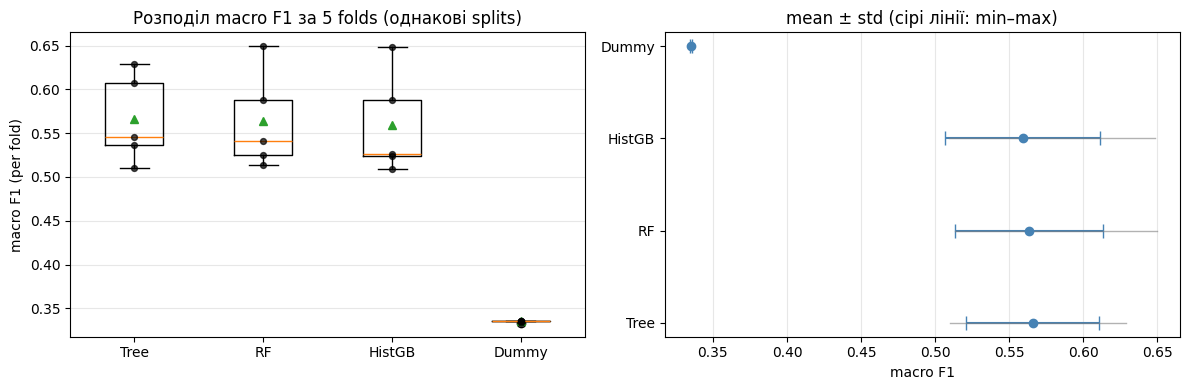

Перекриття інтервалів mean±std з найкращою моделлю:
  RF       vs Tree    : перекриття = True  (Δ mean = -0.0023)
  HistGB   vs Tree    : перекриття = True  (Δ mean = -0.0067)
  Dummy    vs Tree    : перекриття = False  (Δ mean = -0.2307)


In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1) Box-plot / strip-plot macro F1 по folds
order = comparison_full["model"].tolist()
data  = [fold_scores[m] for m in order]
axes[0].boxplot(data, labels=order, showmeans=True)
for i, m in enumerate(order, start=1):
    axes[0].scatter([i] * len(fold_scores[m]), fold_scores[m],
                    alpha=0.7, color="black", s=18, zorder=3)
axes[0].set_ylabel("macro F1 (per fold)")
axes[0].set_title("Розподіл macro F1 за 5 folds (однакові splits)")
axes[0].grid(axis="y", alpha=0.3)

# 2) Mean ± std з min/max
axes[1].errorbar(comparison_full["macro_f1_mean"],
                 comparison_full["model"],
                 xerr=comparison_full["macro_f1_std"],
                 fmt="o", capsize=5, color="steelblue")
for _, row in comparison_full.iterrows():
    axes[1].plot([row["macro_f1_min"], row["macro_f1_max"]],
                 [row["model"]] * 2, color="gray", lw=1, alpha=0.6)
axes[1].set_xlabel("macro F1")
axes[1].set_title("mean ± std (сірі лінії: min–max)")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout(); plt.show()

# --- Перевірка перекриття інтервалів ---
print("Перекриття інтервалів mean±std з найкращою моделлю:")
best_name = comparison_full.iloc[0]["model"]
best_mean = comparison_full.iloc[0]["macro_f1_mean"]
best_std  = comparison_full.iloc[0]["macro_f1_std"]
for _, row in comparison_full.iterrows():
    if row["model"] == best_name: continue
    overlap = not (best_mean - best_std > row["macro_f1_mean"] + row["macro_f1_std"] or
                   row["macro_f1_mean"] - row["macro_f1_std"] > best_mean + best_std)
    print(f"  {row['model']:8s} vs {best_name:8s}: "
          f"перекриття = {overlap}  (Δ mean = {row['macro_f1_mean'] - best_mean:+.4f})")

## Етап 6. Стійкість як властивість ML-рішення

**Мета:** оцінити, наскільки результат залежить від випадкового розбиття,
а не від самої моделі. Гіперпараметри **зафіксовані**.

**Протокол:**
1. Повторюємо 5-fold CV для **10 різних `random_state`**.
2. Для кожної моделі рахуємо: `q_mean`, `std(q)`, `min(q)`, `max(q)` і **range**.
3. OOF-прогнози у кожному повторенні: визначаємо **консенсусний клас** об'єкта
   (мода за 10 повторень) та частку повторень, у яких прогноз ≠ консенсус.
4. Порівнюємо середню нестійкість дерева та ансамблів; рахуємо об'єкти,
   де прогноз змінювався **> 25%** повторень.

In [21]:
from sklearn.model_selection import cross_val_predict

SEEDS = list(range(10))          # 10 повторень
N_SPLITS = CONFIG["cv_folds"]

summary_rows = []
oof_by_model = {}                # модель -> матриця (n_seeds, n_train) OOF-прогнозів

for name, est in models.items():
    seed_means = []
    oof_matrix = np.zeros((len(SEEDS), len(X_train)), dtype=object)

    for s_i, seed in enumerate(SEEDS):
        cv_s = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
        # 1) середнє macro F1 по folds для цього seed
        r = cross_validate(est, X_train, y_train, cv=cv_s,
                           scoring=SCORING_FULL, n_jobs=-1)
        seed_means.append(float(r["test_macro_f1"].mean()))
        # 2) OOF-прогнози (метод predict за замовчуванням)
        oof_matrix[s_i] = cross_val_predict(est, X_train, y_train, cv=cv_s, n_jobs=-1)

    seed_means = np.array(seed_means)
    oof_by_model[name] = oof_matrix

    # консенсусний клас об'єкта за 10 повторень + частка незгоди
    classes = np.unique(y_train)
    consensus = []
    disagree_frac = []
    for j in range(len(X_train)):
        preds = oof_matrix[:, j]
        vals, counts = np.unique(preds, return_counts=True)
        consensus.append(vals[np.argmax(counts)])
        disagree_frac.append(1.0 - counts.max() / len(preds))
    consensus = np.array(consensus)
    disagree_frac = np.array(disagree_frac)

    summary_rows.append({
        "model":              name,
        "q_mean":             seed_means.mean(),
        "q_std":              seed_means.std(),
        "q_min":              seed_means.min(),
        "q_max":              seed_means.max(),
        "q_range":            seed_means.max() - seed_means.min(),
        "mean_disagree":      disagree_frac.mean(),
        "median_disagree":    float(np.median(disagree_frac)),
        "n_objects_gt25%":    int((disagree_frac > 0.25).sum()),
        "share_objects_gt25%": float((disagree_frac > 0.25).mean()),
    })

stability_df = pd.DataFrame(summary_rows).sort_values("q_mean", ascending=False).reset_index(drop=True)
stability_df.round(4)

,model,q_mean,q_std,q_min,q_max,q_range,mean_disagree,median_disagree,n_objects_gt25%,share_objects_gt25%
0,RF,0.5553,0.0123,0.5309,0.5682,0.0373,0.1504,0.1,136,0.2810
1,HistGB,0.5471,0.0101,0.5284,0.5632,0.0348,0.1694,0.1,149,0.3079
2,Tree,0.5425,0.0263,0.4947,0.5832,0.0885,0.2101,0.2,203,0.4194
3,Dummy,0.3352,0.0000,0.3352,0.3352,0.0000,0.0000,0.0,0,0.0000


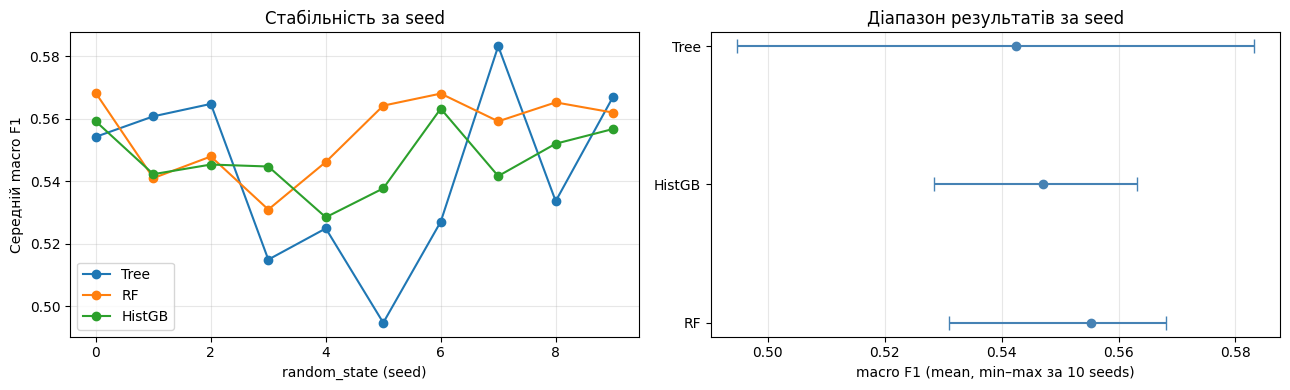

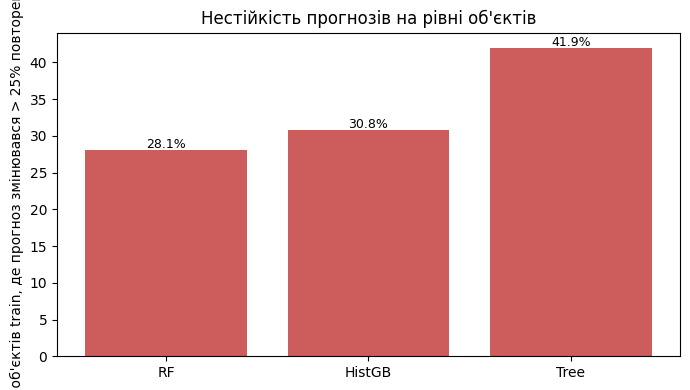

Стійкість за 10 seeds (5-fold CV):


,model,q_mean,q_std,q_range,mean_disagree,n_objects_gt25%,share_objects_gt25%
0,RF,0.5553,0.0123,0.0373,0.1504,136,0.2810
1,HistGB,0.5471,0.0101,0.0348,0.1694,149,0.3079
2,Tree,0.5425,0.0263,0.0885,0.2101,203,0.4194
3,Dummy,0.3352,0.0000,0.0000,0.0000,0,0.0000



H2 (RF стабільніший за дерево) за q_std:
  q_std Tree = 0.0263, q_std RF = 0.0123, q_std GB = 0.0101
  Висновок: ПІДТВЕРДЖЕНО

H4 (важливість ознак змінюється між seeds) — аналіз стабільності прогнозів:
  RF      : mean_disagree=0.1504, об'єктів >25%: 136 (28.1%)
  HistGB  : mean_disagree=0.1694, об'єктів >25%: 149 (30.8%)
  Tree    : mean_disagree=0.2101, об'єктів >25%: 203 (41.9%)

Практичний висновок:
  Лідери RF і HistGB мають перекриття діапазонів — різниця на рівні шуму seed. Обираємо простішу / стабільнішу модель.

Оновлено data\splits\experiment_config.json


In [22]:
# --- 1) Розподіл середніх q по 10 seeds ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for name in models:
    if name == "Dummy":  # надто низький, спотворює масштаб
        continue
    # витягуємо seed-середні з збережених даних
    seed_means = []
    for seed in SEEDS:
        cv_s = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
        r = cross_validate(models[name], X_train, y_train, cv=cv_s,
                           scoring=SCORING_FULL, n_jobs=-1)
        seed_means.append(r["test_macro_f1"].mean())
    axes[0].plot(SEEDS, seed_means, marker="o", label=name)

axes[0].set_xlabel("random_state (seed)"); axes[0].set_ylabel("Середній macro F1")
axes[0].set_title("Стабільність за seed"); axes[0].legend(); axes[0].grid(alpha=0.3)

# --- 2) mean ± range по моделях ---
plot_df = stability_df[stability_df["model"] != "Dummy"]
y = np.arange(len(plot_df))
axes[1].errorbar(plot_df["q_mean"], y,
                 xerr=[plot_df["q_mean"] - plot_df["q_min"],
                       plot_df["q_max"] - plot_df["q_mean"]],
                 fmt="o", capsize=5, color="steelblue")
axes[1].set_yticks(y); axes[1].set_yticklabels(plot_df["model"])
axes[1].set_xlabel("macro F1 (mean, min–max за 10 seeds)")
axes[1].set_title("Діапазон результатів за seed")
axes[1].grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

# --- 3) Частка об'єктів, де прогноз нестабільний ---
fig, ax = plt.subplots(figsize=(7, 4))
non_dummy = stability_df[stability_df["model"] != "Dummy"]
ax.bar(non_dummy["model"], non_dummy["share_objects_gt25%"] * 100, color="indianred")
ax.set_ylabel("% об'єктів train, де прогноз змінювався > 25% повторень")
ax.set_title("Нестійкість прогнозів на рівні об'єктів")
for i, v in enumerate(non_dummy["share_objects_gt25%"] * 100):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

# --- 4) Пояснення та перевірка гіпотез ---
print("Стійкість за 10 seeds (5-fold CV):")
display(stability_df[["model","q_mean","q_std","q_range",
                     "mean_disagree","n_objects_gt25%","share_objects_gt25%"]].round(4))

tree_row = stability_df[stability_df["model"] == "Tree"].iloc[0]
rf_row   = stability_df[stability_df["model"] == "RF"].iloc[0]
gb_row   = stability_df[stability_df["model"] == "HistGB"].iloc[0]

print("\nH2 (RF стабільніший за дерево) за q_std:")
print(f"  q_std Tree = {tree_row['q_std']:.4f}, q_std RF = {rf_row['q_std']:.4f}, "
      f"q_std GB = {gb_row['q_std']:.4f}")
print("  Висновок:",
      "ПІДТВЕРДЖЕНО" if rf_row['q_std'] <= 0.5 * tree_row['q_std'] else "не підтверджено")

print("\nH4 (важливість ознак змінюється між seeds) — аналіз стабільності прогнозів:")
for _, row in stability_df.iterrows():
    if row["model"] == "Dummy":
        continue
    print(f"  {row['model']:8s}: mean_disagree={row['mean_disagree']:.4f}, "
          f"об'єктів >25%: {row['n_objects_gt25%']} "
          f"({row['share_objects_gt25%']*100:.1f}%)")

print("\nПрактичний висновок:")
best_mean_name = stability_df.iloc[0]["model"]
overlap_strict = (
    (stability_df.iloc[0]["q_min"] <= stability_df.iloc[1]["q_max"]) and
    (stability_df.iloc[1]["q_min"] <= stability_df.iloc[0]["q_max"])
)
if overlap_strict:
    print(f"  Лідери {stability_df.iloc[0]['model']} і {stability_df.iloc[1]['model']} "
          f"мають перекриття діапазонів — різниця на рівні шуму seed. "
          f"Обираємо простішу / стабільнішу модель.")
else:
    print(f"  Лідер {best_mean_name} має перевагу, яка не пояснюється вибором seed.")

# --- 5) Дописуємо у конфігурацію ---
final_config["stability"] = {
    "seeds": SEEDS,
    "summary": stability_df.to_dict(orient="records"),
}
with open(SPLIT_DIR / "experiment_config.json", "w") as f:
    json.dump(final_config, f, indent=2, ensure_ascii=False, default=str)
print("\nОновлено", SPLIT_DIR / "experiment_config.json")